# Unified MIMIC Target Workflow

Run one MIMIC target/window end to end. Set `CLUSTER = False` for classifier-only explanations, or `CLUSTER = True` to train/load the explanation-value autoencoder, select clusters per predicted class, test pattern similarity, and plot class/cluster patterns.

## 1. Imports and Project Paths

In [1]:
from __future__ import annotations

import json
import logging
import os
import re
import shutil
import sys
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "interpretable_ts_vit").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from interpretable_ts_vit.autoencoder import (
    _write_explanation_aggregates,
    create_explanation_value_embeddings,
    train_explanation_value_autoencoder,
)
from interpretable_ts_vit.binning import TimeSeriesBinner
from interpretable_ts_vit.config import ClusterConfig, DataConfig, ExplainConfig, ModelConfig, TrainConfig
from interpretable_ts_vit.data_modules import GenericCSVDataModule
from interpretable_ts_vit.datasets import configured_variables_for_target, load_mimic_targets_config
from interpretable_ts_vit.io import load_split
from interpretable_ts_vit.model_modules import ViTTimeSeriesModule
from interpretable_ts_vit.pipeline import _denormalized_patient_value_maps
from interpretable_ts_vit.visualization import plot_value_heatmap, value_ranges_by_variable

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(name)s: %(message)s", force=True)
logger = logging.getLogger("unified_mimic_target_workflow")
logger.info("Project root: %s", PROJECT_ROOT)


2026-07-15 20:21:25,675 INFO unified_mimic_target_workflow: Project root: /home/michalwe/Interpretable-ViT-for-Timeseries


## 2. User Settings and Configs

In [ ]:
TARGET = "hypokalemia"
WINDOW = "obs24_target8_gap0"
EXPERIMENT_NAME = "vit_baseline"
SPLIT = "test"
CLUSTER = False

FORCE_PREPARE = False
FORCE_TRAIN = False
FORCE_EVALUATE = False
FORCE_EXPLAIN = False
FORCE_AUTOENCODER = False
FORCE_EMBEDDINGS = False
FORCE_CLUSTER = False
FORCE_PLOTS = False

N_CLUSTER_CANDIDATES = range(2, 13)
RANDOM_STATE = 42
SIGNIFICANCE_ALPHA = 0.05
PATTERN_TOP_IMPORTANCE_PERCENTAGE = 0.1
PATTERN_VALUE_SCALE = "z_score"  # use "raw" to compare denormalized values
SHOW_VALUES = True
USE_NORMAL_RANGES = True

DATA_ROOT = PROJECT_ROOT / "data" / "mimic_targets"
PROCESSED_ROOT = DATA_ROOT / "processed"
RUN_ROOT = PROJECT_ROOT / "runs" / "mimic_targets" / EXPERIMENT_NAME
MIMIC_TARGETS_CONFIG_PATH = PROJECT_ROOT / "configs" / "datasets" / "mimic" / "targets.yaml"
NORMAL_RANGES_PATH = PROJECT_ROOT / "src" / "interpretable_ts_vit" / "normal_ranges.json"

source_dir = DATA_ROOT / WINDOW / TARGET
processed_dir = PROCESSED_ROOT / WINDOW / TARGET
run_dir = RUN_ROOT / WINDOW / TARGET
clusters_dir = run_dir / "clusters" / SPLIT
explanations_root = run_dir / "explanations"
pattern_heatmap_dir = run_dir / "pattern_heatmaps" / SPLIT

required_splits = ["train", "val", SPLIT] if CLUSTER else [SPLIT]

base_data_config = DataConfig(granularity="30min", aggregation="mean", val_fraction=0.2, test_fraction=0.2, random_state=RANDOM_STATE)
model_config = ModelConfig(patch_size=(1, 4), embed_dim=64, depth=2, num_heads=4, mlp_ratio=2.0, dropout=0.1)
train_config = TrainConfig(batch_size=16, epochs=10, learning_rate=1e-3, weight_decay=1e-4, device="auto", early_stopping_patience=3, restore_best_model=True, verbose=True)
explain_config = ExplainConfig(method="grad_attention_rollout", target_class=None, batch_size=16)
cluster_config = ClusterConfig(feature_mode="autoencoder", method="kmeans", n_clusters=8, autoencoder_latent_dim=16, autoencoder_epochs=50, autoencoder_learning_rate=1e-3, autoencoder_batch_size=32, autoencoder_early_stopping_patience=10, show_values=SHOW_VALUES, use_normal_ranges=USE_NORMAL_RANGES)

pd.DataFrame([
    {"setting": "TARGET", "value": TARGET},
    {"setting": "WINDOW", "value": WINDOW},
    {"setting": "EXPERIMENT_NAME", "value": EXPERIMENT_NAME},
    {"setting": "SPLIT", "value": SPLIT},
    {"setting": "CLUSTER", "value": CLUSTER},
    {"setting": "run_dir", "value": str(run_dir)},
])


,setting,value
0,TARGET,hypotension
1,WINDOW,obs24_target8_gap0
2,EXPERIMENT_NAME,vit_baseline
3,SPLIT,test
4,CLUSTER,False
5,run_dir,/home/michalwe/Interpretable-ViT-for-Timeserie...


## 3. Build Data and Model Modules

In [3]:
def safe_path_component(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_") or "class"


def load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as fh:
        return json.load(fh)


def allowed_variables_for_target(target: str) -> list[str]:
    mimic_config = load_mimic_targets_config(MIMIC_TARGETS_CONFIG_PATH)
    allowed = configured_variables_for_target(mimic_config, target)
    if not allowed:
        raise ValueError(f"No YAML-configured variables found for target={target!r} in {MIMIC_TARGETS_CONFIG_PATH}")
    logger.info("Loaded %d YAML-configured variables for target=%s", len(allowed), target)
    return allowed


def build_data_module() -> GenericCSVDataModule:
    records_path = source_dir / "records.csv"
    labels_path = source_dir / "labels.csv"
    missing = [path for path in [records_path, labels_path] if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing source file(s): " + ", ".join(str(path) for path in missing))
    data_config = replace(base_data_config, allowed_variables=allowed_variables_for_target(TARGET))
    return GenericCSVDataModule(records_path=records_path, labels_path=labels_path, processed_dir=processed_dir, data_config=data_config)


def build_model_module() -> ViTTimeSeriesModule:
    return ViTTimeSeriesModule(run_dir=run_dir, model_config=model_config, train_config=train_config, explain_config=explain_config, cluster_config=cluster_config)


def remove_path(path: Path) -> None:
    path = Path(path)
    if path.is_dir():
        shutil.rmtree(path)
    elif path.exists():
        path.unlink()


def normal_ranges_arg():
    return NORMAL_RANGES_PATH if USE_NORMAL_RANGES else None


def jsonable(value):
    if hasattr(value, "__dataclass_fields__"):
        return {key: jsonable(getattr(value, key)) for key in value.__dataclass_fields__}
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, range):
        return list(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {str(key): jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [jsonable(item) for item in value]
    return value


def selected_window_config() -> dict:
    mimic_config = load_mimic_targets_config(MIMIC_TARGETS_CONFIG_PATH)
    for window in mimic_config.windows:
        if window.name == WINDOW:
            return jsonable(window)
    return {"name": WINDOW, "warning": "Window was not found in the MIMIC targets config."}


def save_experiment_config(data_module: GenericCSVDataModule) -> Path:
    run_dir.mkdir(parents=True, exist_ok=True)
    config_payload = {
        "target": TARGET,
        "window": WINDOW,
        "experiment_name": EXPERIMENT_NAME,
        "split": SPLIT,
        "cluster_enabled": CLUSTER,
        "window_config": selected_window_config(),
        "paths": {
            "source_dir": source_dir,
            "processed_dir": processed_dir,
            "run_dir": run_dir,
            "mimic_targets_config_path": MIMIC_TARGETS_CONFIG_PATH,
            "normal_ranges_path": NORMAL_RANGES_PATH if USE_NORMAL_RANGES else None,
        },
        "data_config": data_module.data_config,
        "model_config": model_config,
        "train_config": train_config,
        "explain_config": explain_config,
        "cluster_config": cluster_config,
        "analysis_settings": {
            "n_cluster_candidates": N_CLUSTER_CANDIDATES,
            "random_state": RANDOM_STATE,
            "significance_alpha": SIGNIFICANCE_ALPHA,
            "pattern_top_importance_percentage": PATTERN_TOP_IMPORTANCE_PERCENTAGE,
            "pattern_value_scale": PATTERN_VALUE_SCALE,
            "show_values": SHOW_VALUES,
            "use_normal_ranges": USE_NORMAL_RANGES,
        },
        "force_flags": {
            "force_prepare": FORCE_PREPARE,
            "force_train": FORCE_TRAIN,
            "force_evaluate": FORCE_EVALUATE,
            "force_explain": FORCE_EXPLAIN,
            "force_autoencoder": FORCE_AUTOENCODER,
            "force_embeddings": FORCE_EMBEDDINGS,
            "force_cluster": FORCE_CLUSTER,
            "force_plots": FORCE_PLOTS,
        },
    }
    path = run_dir / "experiment_config.json"
    path.write_text(json.dumps(jsonable(config_payload), indent=2), encoding="utf-8")
    logger.info("Saved experiment configuration to %s", path)
    return path


data = build_data_module()
model = build_model_module()
experiment_config_path = save_experiment_config(data)

pd.DataFrame({
    "artifact": ["records", "labels", "processed_dir", "run_dir"],
    "path": [str(source_dir / "records.csv"), str(source_dir / "labels.csv"), str(processed_dir), str(run_dir)],
})


2026-07-15 20:21:25,739 INFO unified_mimic_target_workflow: Loaded 30 YAML-configured variables for target=hypotension
2026-07-15 20:21:25,755 INFO unified_mimic_target_workflow: Saved experiment configuration to /home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/experiment_config.json


,artifact,path
0,records,/home/michalwe/Interpretable-ViT-for-Timeserie...
1,labels,/home/michalwe/Interpretable-ViT-for-Timeserie...
2,processed_dir,/home/michalwe/Interpretable-ViT-for-Timeserie...
3,run_dir,/home/michalwe/Interpretable-ViT-for-Timeserie...


## 4. Prepare or Load Tensor Data

In [4]:
prepared_required = [processed_dir / "binner.json", processed_dir / "train.npz", processed_dir / "val.npz", processed_dir / "test.npz"]
if FORCE_PREPARE and processed_dir.exists():
    logger.warning("FORCE_PREPARE=True; removing %s", processed_dir)
    remove_path(processed_dir)

if all(path.exists() for path in prepared_required):
    logger.info("Prepared tensors already exist under %s", processed_dir)
else:
    logger.info("Preparing tensors under %s", processed_dir)
    data.prepare()

data.load()
binner = TimeSeriesBinner.load(processed_dir / "binner.json")
split_datasets = {split: load_split(processed_dir / f"{split}.npz") for split in ["train", "val", "test"]}

pd.DataFrame([
    {"split": split, "patients": len(dataset), "x_shape": tuple(dataset.x.shape)}
    for split, dataset in split_datasets.items()
])


2026-07-15 20:21:25,768 INFO unified_mimic_target_workflow: Prepared tensors already exist under /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_targets/processed/obs24_target8_gap0/hypotension
2026-07-15 20:21:25,768 INFO interpretable_ts_vit.data_modules.base: Loading data module metadata from /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_targets/processed/obs24_target8_gap0/hypotension/binner.json
2026-07-15 20:21:25,769 INFO interpretable_ts_vit.binning: Loading binner metadata from /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_targets/processed/obs24_target8_gap0/hypotension/binner.json
2026-07-15 20:21:25,770 INFO interpretable_ts_vit.binning: Loaded binner metadata from /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_targets/processed/obs24_target8_gap0/hypotension/binner.json: variables=30, time_bins=48
2026-07-15 20:21:25,770 INFO interpretable_ts_vit.data_modules.base: Loaded data module metadata from /home/michalwe/Interpretabl

,split,patients,x_shape
0,train,44897,"(44897, 2, 30, 48)"
1,val,14966,"(14966, 2, 30, 48)"
2,test,14966,"(14966, 2, 30, 48)"


## 5. Train or Load Model

In [5]:
model_path = run_dir / "model.pt"
if FORCE_TRAIN and model_path.exists():
    logger.warning("FORCE_TRAIN=True; removing %s", model_path)
    remove_path(model_path)

if model_path.exists():
    logger.info("Trained model already exists at %s", model_path)
    train_metrics = load_json(run_dir / "metrics.json") if (run_dir / "metrics.json").exists() else None
else:
    logger.info("Training model because %s is missing", model_path)
    train_metrics = model.fit(data)

if train_metrics is not None:
    display(pd.DataFrame([train_metrics]))
else:
    print(f"Loaded model: {model_path}")


2026-07-15 20:21:27,505 INFO unified_mimic_target_workflow: Trained model already exists at /home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/model.pt


,accuracy,macro_f1,confusion_matrix,auc,auroc,tpr,fpr,tnr,fnr,ppv,history,epochs_ran,stopped_early,best_epoch,best_monitor,best_monitor_value
0,0.814045,0.774043,"[[2943, 1599], [1184, 9240]]",0.872739,0.872739,0.886416,0.352048,0.647952,0.113584,0.852477,"[{'epoch': 1.0, 'train_loss': 0.49271702018838...",5,True,2,val_loss,0.403261


## 6. Evaluate and Print Metrics

In [6]:
metrics_path = run_dir / f"{SPLIT}_evaluation_metrics.json"
predictions_path = run_dir / f"{SPLIT}_predictions.csv"
if FORCE_EVALUATE:
    for path in [metrics_path, predictions_path]:
        if path.exists():
            logger.warning("FORCE_EVALUATE=True; removing %s", path)
            remove_path(path)

if metrics_path.exists() and predictions_path.exists():
    logger.info("Loading existing evaluation artifacts for split=%s", SPLIT)
    evaluation_metrics = load_json(metrics_path)
else:
    logger.info("Evaluating model for split=%s", SPLIT)
    evaluation_metrics = model.evaluate(data, split=SPLIT)

model_evaluation_metrics_path = run_dir / f"model_evaluation_metrics_{SPLIT}.json"
model_evaluation_metrics_path.write_text(json.dumps(jsonable(evaluation_metrics), indent=2), encoding="utf-8")
logger.info("Saved model evaluation metrics to %s", model_evaluation_metrics_path)

predictions = pd.read_csv(predictions_path, dtype={"patient_id": str})
display(pd.DataFrame([evaluation_metrics]))
display(predictions.head())


2026-07-15 20:21:27,526 INFO unified_mimic_target_workflow: Loading existing evaluation artifacts for split=test
2026-07-15 20:21:27,528 INFO unified_mimic_target_workflow: Saved model evaluation metrics to /home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/model_evaluation_metrics_test.json


,accuracy,macro_f1,confusion_matrix,auc,auroc,tpr,fpr,tnr,fnr,ppv
0,0.818255,0.780041,"[[3004, 1539], [1181, 9242]]",0.876732,0.876732,0.886693,0.338763,0.661237,0.113307,0.857249


,patient_id,predicted_label,prob_False,prob_True
0,30002415,False,0.839452,0.160548
1,30003087,False,0.868963,0.131037
2,30003306,True,0.020466,0.979534
3,30004462,False,0.501660,0.498340
4,30004811,True,0.032396,0.967604


## 7. Create or Load Explanations

In [7]:
def explanations_complete(split: str) -> bool:
    explanations_dir = explanations_root / split
    split_path = run_dir / f"{split}.npz"
    if not explanations_dir.exists() or not split_path.exists():
        return False
    dataset = load_split(split_path)
    return all((explanations_dir / f"{patient_id}.npy").exists() for patient_id in dataset.patient_ids)


# Model training copies prepared splits into run_dir. If the model was already present from an older run,
# make sure the split tensors expected by evaluation/explanation are also present there.
for split in ["train", "val", "test"]:
    src = processed_dir / f"{split}.npz"
    dst = run_dir / f"{split}.npz"
    if src.exists() and not dst.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copyfile(src, dst)
for name in ["binner.json", "variable_vocab.json"]:
    src = processed_dir / name
    dst = run_dir / name
    if src.exists() and not dst.exists():
        shutil.copyfile(src, dst)

if FORCE_EXPLAIN:
    for split in required_splits:
        path = explanations_root / split
        if path.exists():
            logger.warning("FORCE_EXPLAIN=True; removing %s", path)
            remove_path(path)

explanation_dirs = {}
for split in required_splits:
    if explanations_complete(split):
        logger.info("Explanations already exist for split=%s", split)
        explanation_dirs[split] = explanations_root / split
    else:
        logger.info("Creating explanations for split=%s", split)
        explanation_dirs[split] = model.explain(data, split=split, show_progress=True)

pd.DataFrame([
    {"split": split, "explanations_dir": str(path), "n_files": len(list(path.glob("*.npy")))}
    for split, path in explanation_dirs.items()
])


2026-07-15 20:21:27,562 INFO interpretable_ts_vit.io: Loading split from /home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/test.npz
2026-07-15 20:21:27,906 INFO interpretable_ts_vit.data: Created BinnedTimeSeriesDataset: x_shape=(14966, 2, 30, 48), labels=True, patient_ids=True
2026-07-15 20:21:27,907 INFO interpretable_ts_vit.io: Loaded split from /home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/test.npz: patients=14966, x_shape=(14966, 2, 30, 48), labels=True
2026-07-15 20:21:33,132 INFO unified_mimic_target_workflow: Explanations already exist for split=test


,split,explanations_dir,n_files
0,test,/home/michalwe/Interpretable-ViT-for-Timeserie...,14966


## 8. Train or Load Autoencoder

In [8]:
def clear_autoencoder_artifacts():
    for name in ["autoencoder.pt", "autoencoder_metrics.json", "autoencoder_training_metadata.json", "autoencoder_losses.json"]:
        path = clusters_dir / name
        if path.exists():
            remove_path(path)


trained_autoencoder = None
if CLUSTER:
    clusters_dir.mkdir(parents=True, exist_ok=True)
    if FORCE_AUTOENCODER:
        logger.warning("FORCE_AUTOENCODER=True; removing cached autoencoder artifacts under %s", clusters_dir)
        clear_autoencoder_artifacts()

    train_dataset = load_split(run_dir / "train.npz")
    val_dataset = load_split(run_dir / "val.npz")
    binner = TimeSeriesBinner.load(run_dir / "binner.json")
    trained_autoencoder = train_explanation_value_autoencoder(
        explanations_root / "train",
        _denormalized_patient_value_maps(train_dataset, binner),
        validation_explanations=explanations_root / "val",
        validation_values=_denormalized_patient_value_maps(val_dataset, binner),
        output_dir=clusters_dir,
        latent_dim=cluster_config.autoencoder_latent_dim,
        epochs=cluster_config.autoencoder_epochs,
        learning_rate=cluster_config.autoencoder_learning_rate,
        batch_size=cluster_config.autoencoder_batch_size,
        device=train_config.device,
        early_stopping_patience=cluster_config.autoencoder_early_stopping_patience,
        patch_size=model_config.patch_size,
    )
    display(pd.DataFrame([trained_autoencoder["metrics"]]))
else:
    print("CLUSTER=False; skipping autoencoder.")


CLUSTER=False; skipping autoencoder.


## 9. Create or Load Test Embeddings

In [9]:
def clear_embedding_artifacts():
    for name in ["autoencoder_embeddings.csv", "autoencoder_embedding_metadata.json"]:
        path = clusters_dir / name
        if path.exists():
            remove_path(path)


embedded_split = None
embedding_frame = None
if CLUSTER:
    if FORCE_EMBEDDINGS:
        logger.warning("FORCE_EMBEDDINGS=True; removing cached embedding artifacts under %s", clusters_dir)
        clear_embedding_artifacts()

    test_dataset = load_split(run_dir / f"{SPLIT}.npz")
    embedded_split = create_explanation_value_embeddings(
        explanations_root / SPLIT,
        _denormalized_patient_value_maps(test_dataset, binner),
        model=trained_autoencoder["model"],
        preprocessor=trained_autoencoder["preprocessor"],
        output_dir=clusters_dir,
        batch_size=cluster_config.autoencoder_batch_size,
        device=train_config.device,
    )
    embedding_frame = embedded_split.get("embedding_frame")
    if embedding_frame is None:
        embedding_frame = pd.read_csv(clusters_dir / "autoencoder_embeddings.csv", dtype={"patient_id": str})
    display(embedding_frame.head())
else:
    print("CLUSTER=False; skipping embeddings.")


CLUSTER=False; skipping embeddings.


## 10. Silhouette-Select and Save Per-Class Clusters

In [10]:
def load_explanation_maps(explanations_dir: Path) -> dict[str, np.ndarray]:
    return {path.stem: np.load(path).astype(np.float64) for path in sorted(explanations_dir.glob("*.npy"))}


def feature_columns(frame: pd.DataFrame) -> list[str]:
    return [column for column in frame.columns if column != "patient_id" and pd.api.types.is_numeric_dtype(frame[column])]


def silhouette_scores_for_class(group: pd.DataFrame, columns: list[str], candidates, random_state=RANDOM_STATE) -> pd.DataFrame:
    scaled = StandardScaler().fit_transform(group[columns].to_numpy(dtype=np.float64))
    rows = []
    for candidate in candidates:
        n_clusters = int(candidate)
        if n_clusters < 2 or n_clusters >= len(group):
            continue
        labels = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10).fit_predict(scaled)
        rows.append({"n_clusters": n_clusters, "silhouette_score": float(silhouette_score(scaled, labels)), "n_patients": len(group)})
    return pd.DataFrame(rows)


def cluster_frame_for_class(group: pd.DataFrame, columns: list[str], n_clusters: int, random_state=RANDOM_STATE) -> pd.DataFrame:
    scaled = StandardScaler().fit_transform(group[columns].to_numpy(dtype=np.float64))
    n_clusters = max(1, min(int(n_clusters), len(group)))
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10).fit(scaled)
    labels = kmeans.labels_.astype(int)
    distances = np.linalg.norm(scaled - kmeans.cluster_centers_[labels], axis=1)
    frame = pd.DataFrame({
        "patient_id": group["patient_id"].astype(str).to_numpy(),
        "predicted_label": group["predicted_label"].astype(str).to_numpy(),
        "cluster": labels,
        "distance_to_centroid": distances,
        "is_centroid": False,
    })
    for cluster in sorted(frame["cluster"].unique()):
        idx = frame.loc[frame["cluster"] == cluster, "distance_to_centroid"].idxmin()
        frame.loc[idx, "is_centroid"] = True
    return frame


def write_silhouette_cluster_outputs(assignments: pd.DataFrame, selected_by_class: dict, silhouette_scores: pd.DataFrame, explanations: dict[str, np.ndarray]) -> None:
    clusters_dir.mkdir(parents=True, exist_ok=True)
    assignments.to_csv(clusters_dir / "cluster_assignments.csv", index=False)
    assignments.loc[assignments["is_centroid"]].to_csv(clusters_dir / "cluster_centroids.csv", index=False)
    _write_explanation_aggregates(clusters_dir, assignments, explanations)
    metadata = {
        "feature_mode": "autoencoder",
        "class_specific": True,
        "clustering_method": "kmeans",
        "cluster_selection": "best silhouette score per predicted_label",
        "candidate_clusters": [int(value) for value in N_CLUSTER_CANDIDATES],
        "n_clusters_used": {str(label): int(values["n_clusters"]) for label, values in selected_by_class.items()},
        "silhouette_score_by_class": {str(label): float(values["silhouette_score"]) for label, values in selected_by_class.items()},
        "centroid_definition": "nearest patient to cluster centroid in scaled autoencoder latent space",
    }
    if (clusters_dir / "autoencoder_metrics.json").exists():
        metadata["autoencoder_metrics"] = load_json(clusters_dir / "autoencoder_metrics.json")
    (clusters_dir / "cluster_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    silhouette_scores.to_csv(clusters_dir / "silhouette_cluster_scores.csv", index=False)


assignments = None
silhouette_scores = pd.DataFrame()
if CLUSTER:
    assignments_path = clusters_dir / "cluster_assignments.csv"
    if assignments_path.exists() and not FORCE_CLUSTER:
        logger.info("Loading existing cluster assignments from %s", assignments_path)
        assignments = pd.read_csv(assignments_path, dtype={"patient_id": str, "predicted_label": str})
    else:
        logger.info("Selecting clusters per predicted class by silhouette score")
        predictions = pd.read_csv(predictions_path, dtype={"patient_id": str, "predicted_label": str})
        frame = embedding_frame.merge(predictions[["patient_id", "predicted_label"]], on="patient_id", how="inner")
        columns = feature_columns(embedding_frame)
        assignment_frames = []
        score_frames = []
        selected_by_class = {}
        for predicted_label, group in frame.groupby("predicted_label", sort=True):
            scores = silhouette_scores_for_class(group, columns, N_CLUSTER_CANDIDATES)
            if scores.empty:
                selected_n = 1
                selected_score = np.nan
            else:
                best = scores.sort_values("silhouette_score", ascending=False).iloc[0]
                selected_n = int(best["n_clusters"])
                selected_score = float(best["silhouette_score"])
                score_frames.append(scores.assign(predicted_label=str(predicted_label)))
            selected_by_class[str(predicted_label)] = {"n_clusters": selected_n, "silhouette_score": selected_score, "n_patients": len(group)}
            assignment_frames.append(cluster_frame_for_class(group, columns, selected_n))
        assignments = pd.concat(assignment_frames, ignore_index=True)
        silhouette_scores = pd.concat(score_frames, ignore_index=True) if score_frames else pd.DataFrame()
        test_explanations = load_explanation_maps(explanations_root / SPLIT)
        write_silhouette_cluster_outputs(assignments, selected_by_class, silhouette_scores, test_explanations)
    display(assignments.groupby(["predicted_label", "cluster"]).size().rename("patients").reset_index())
else:
    print("CLUSTER=False; skipping clustering.")


CLUSTER=False; skipping clustering.


## 11. Statistical Pattern Similarity Tests

In [11]:
def dataset_value_tensor_for_similarity(dataset, binner, value_scale="z_score"):
    x = dataset.x.detach().cpu().numpy()
    values = x[:, 0].astype(np.float64)
    observed = x[:, 1].astype(bool)
    if value_scale == "raw":
        means = np.array([binner.means_.get(variable, 0.0) for variable in binner.variable_vocab_], dtype=np.float64)[:, None]
        stds = np.array([binner.stds_.get(variable, 1.0) for variable in binner.variable_vocab_], dtype=np.float64)[:, None]
        values = values * stds[None, :, :] + means[None, :, :]
    elif value_scale != "z_score":
        raise ValueError("value_scale must be 'z_score' or 'raw'.")
    return np.where(observed, values, np.nan)


def nanmean_without_warning(values, axis=0):
    finite = np.isfinite(values)
    counts = finite.sum(axis=axis)
    totals = np.nansum(values, axis=axis)
    result = np.full_like(totals, np.nan, dtype=np.float64)
    np.divide(totals, counts, out=result, where=counts > 0)
    return result


def top_importance_sparse_values(value_matrix, importance_matrix, top_fraction):
    finite_mask = np.isfinite(value_matrix) & np.isfinite(importance_matrix)
    finite_importance = importance_matrix[finite_mask]
    if finite_importance.size == 0:
        return np.zeros_like(value_matrix, dtype=np.float64), np.zeros_like(value_matrix, dtype=bool)
    cutoff = np.quantile(finite_importance, 1.0 - float(top_fraction))
    top_mask = finite_mask & (importance_matrix >= cutoff)
    sparse = np.zeros_like(value_matrix, dtype=np.float64)
    sparse[top_mask] = value_matrix[top_mask]
    return sparse, top_mask


def cosine_similarity(a, b, eps=1e-12):
    a = np.nan_to_num(np.asarray(a, dtype=np.float64).ravel(), nan=0.0)
    b = np.nan_to_num(np.asarray(b, dtype=np.float64).ravel(), nan=0.0)
    denominator = np.linalg.norm(a) * np.linalg.norm(b)
    if denominator <= eps:
        return np.nan
    return float(np.dot(a, b) / denominator)


def more_similar_class(similarity_to_true, similarity_to_false):
    if not np.isfinite(similarity_to_true) or not np.isfinite(similarity_to_false):
        return np.nan
    if similarity_to_true == similarity_to_false:
        return "tie"
    return "True" if similarity_to_true > similarity_to_false else "False"


def mean_importance_for_patient_ids(patient_ids, explanation_maps):
    matrices = [explanation_maps[str(patient_id)] for patient_id in patient_ids if str(patient_id) in explanation_maps]
    if not matrices:
        raise ValueError("No explanation matrices found for the requested patients.")
    return np.mean(matrices, axis=0)


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=np.float64)
    adjusted = np.full_like(p_values, np.nan, dtype=np.float64)
    finite = np.isfinite(p_values)
    finite_p_values = p_values[finite]
    if finite_p_values.size == 0:
        return adjusted
    order = np.argsort(finite_p_values)
    ranked = finite_p_values[order]
    corrected = ranked * finite_p_values.size / np.arange(1, finite_p_values.size + 1)
    corrected = np.minimum.accumulate(corrected[::-1])[::-1]
    corrected = np.clip(corrected, 0.0, 1.0)
    finite_adjusted = np.empty_like(corrected)
    finite_adjusted[order] = corrected
    adjusted[finite] = finite_adjusted
    return adjusted


test_dataset = load_split(run_dir / f"{SPLIT}.npz")
binner = TimeSeriesBinner.load(run_dir / "binner.json")
value_tensor = dataset_value_tensor_for_similarity(test_dataset, binner, value_scale=PATTERN_VALUE_SCALE)
plot_value_tensor = dataset_value_tensor_for_similarity(test_dataset, binner, value_scale="raw")
patient_ids = np.array([str(patient_id) for patient_id in test_dataset.patient_ids])
patient_to_index = {patient_id: index for index, patient_id in enumerate(patient_ids)}
explanation_maps = load_explanation_maps(explanations_root / SPLIT)

predictions = pd.read_csv(predictions_path, dtype={"patient_id": str, "predicted_label": str})
assignment_labels = predictions[["patient_id", "predicted_label"]].drop_duplicates().copy()
class_labels = sorted(assignment_labels["predicted_label"].astype(str).unique())
if len(class_labels) != 2:
    raise ValueError(f"Expected binary class labels for similarity tests, found: {class_labels}")
false_like, true_like = class_labels[0], class_labels[1]

class_patterns = {}
class_plot_matrices = {}
class_importance_matrices = {}
for class_label in class_labels:
    class_patient_ids = assignment_labels.loc[assignment_labels["predicted_label"] == class_label, "patient_id"].astype(str).tolist()
    class_indices = [patient_to_index[patient_id] for patient_id in class_patient_ids if patient_id in patient_to_index]
    class_mean_values = nanmean_without_warning(value_tensor[class_indices], axis=0)
    class_plot_values = nanmean_without_warning(plot_value_tensor[class_indices], axis=0)
    class_mean_importance = mean_importance_for_patient_ids(class_patient_ids, explanation_maps)
    class_patterns[class_label], _ = top_importance_sparse_values(class_mean_values, class_mean_importance, PATTERN_TOP_IMPORTANCE_PERCENTAGE)
    class_plot_matrices[class_label] = class_plot_values
    class_importance_matrices[class_label] = class_mean_importance

true_labels = None
if test_dataset.y is not None:
    y = test_dataset.y.detach().cpu().numpy().astype(int)
    true_labels = [binner.index_to_label_[label] if 0 <= label < len(binner.index_to_label_) else str(label) for label in y]

rows = []
patient_sparse_patterns = {}
for index, patient_id in enumerate(patient_ids):
    if patient_id not in explanation_maps:
        continue
    patient_pattern, _ = top_importance_sparse_values(value_tensor[index], explanation_maps[patient_id], PATTERN_TOP_IMPORTANCE_PERCENTAGE)
    patient_sparse_patterns[patient_id] = patient_pattern
    similarity_to_true = cosine_similarity(patient_pattern, class_patterns[true_like])
    similarity_to_false = cosine_similarity(patient_pattern, class_patterns[false_like])
    rows.append({
        "patient_id": patient_id,
        "true_label": None if true_labels is None else str(true_labels[index]),
        f"similarity_to_{true_like}": similarity_to_true,
        f"similarity_to_{false_like}": similarity_to_false,
        "more_similar_class": more_similar_class(similarity_to_true, similarity_to_false),
    })
pattern_similarity = pd.DataFrame(rows)


def pattern_class_separation_test(frame, pattern_label):
    other_label = false_like if pattern_label == true_like else true_like
    pattern_col = f"similarity_to_{pattern_label}"
    pattern_scores = frame.loc[frame["true_label"].astype(str) == pattern_label, pattern_col].dropna()
    other_scores = frame.loc[frame["true_label"].astype(str) == other_label, pattern_col].dropna()
    mean_difference = pattern_scores.mean() - other_scores.mean()
    p_value = np.nan
    if len(pattern_scores) > 0 and len(other_scores) > 0:
        p_value = float(stats.mannwhitneyu(pattern_scores, other_scores, alternative="greater").pvalue)
    winner = np.nan
    if np.isfinite(mean_difference):
        winner = pattern_label if mean_difference > 0 else other_label
    if mean_difference == 0:
        winner = "tie"
    return {"pattern": pattern_label, "more_similar_class": winner, "n_same_class": len(pattern_scores), "n_other_class": len(other_scores), "mean_same_class": float(pattern_scores.mean()), "mean_other_class": float(other_scores.mean()), "mean_difference": float(mean_difference), "p_value": p_value, "is_significant": bool((mean_difference > 0) and np.isfinite(p_value) and p_value < SIGNIFICANCE_ALPHA)}

similarity_distribution_tests = pd.DataFrame([pattern_class_separation_test(pattern_similarity, pattern_label) for pattern_label in class_labels])
pattern_similarity_path = run_dir / f"{SPLIT}_pattern_similarity.csv"
class_similarity_tests_path = run_dir / f"{SPLIT}_class_similarity_tests.csv"
pattern_similarity.to_csv(pattern_similarity_path, index=False)
similarity_distribution_tests.to_csv(class_similarity_tests_path, index=False)
logger.info("Saved patient pattern similarities to %s", pattern_similarity_path)
logger.info("Saved class similarity tests to %s", class_similarity_tests_path)
display(pattern_similarity.head())
display(similarity_distribution_tests)


2026-07-15 20:21:33,330 INFO interpretable_ts_vit.io: Loading split from /home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/test.npz
2026-07-15 20:21:33,674 INFO interpretable_ts_vit.data: Created BinnedTimeSeriesDataset: x_shape=(14966, 2, 30, 48), labels=True, patient_ids=True
2026-07-15 20:21:33,674 INFO interpretable_ts_vit.io: Loaded split from /home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/test.npz: patients=14966, x_shape=(14966, 2, 30, 48), labels=True
2026-07-15 20:21:33,675 INFO interpretable_ts_vit.binning: Loading binner metadata from /home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/binner.json
2026-07-15 20:21:33,676 INFO interpretable_ts_vit.binning: Loaded binner metadata from /home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/bi

,patient_id,true_label,similarity_to_True,similarity_to_False,more_similar_class
0,30002415,False,-0.035548,0.073352,False
1,30003087,False,-0.033535,0.064693,False
2,30003306,True,0.088815,-0.282869,True
3,30004462,True,0.070288,-0.241356,True
4,30004811,True,0.087029,-0.281141,True


,pattern,more_similar_class,n_same_class,n_other_class,mean_same_class,mean_other_class,mean_difference,p_value,is_significant
0,False,False,4543,10423,-0.006511,-0.096295,0.089785,0.0,True
1,True,True,10423,4543,0.062759,0.015296,0.047463,0.0,True


## 11b. Cluster Pattern Similarity Tests

In [12]:
cluster_similarity_distribution_tests = pd.DataFrame()
cluster_patterns = {}
cluster_plot_matrices = {}
cluster_importance_matrices = {}

if CLUSTER:
    def cluster_pattern_similarity_test(cluster_label, cluster_number, cluster_patient_ids):
        cluster_label = str(cluster_label)
        cluster_number = int(cluster_number)
        other_label = false_like if cluster_label == true_like else true_like
        cluster_indices = [patient_to_index[str(patient_id)] for patient_id in cluster_patient_ids if str(patient_id) in patient_to_index]
        cluster_mean_values = nanmean_without_warning(value_tensor[cluster_indices], axis=0)
        cluster_plot_values = nanmean_without_warning(plot_value_tensor[cluster_indices], axis=0)
        cluster_mean_importance = mean_importance_for_patient_ids(cluster_patient_ids, explanation_maps)
        cluster_pattern, _ = top_importance_sparse_values(cluster_mean_values, cluster_mean_importance, PATTERN_TOP_IMPORTANCE_PERCENTAGE)
        cluster_patterns[(cluster_label, cluster_number)] = cluster_pattern
        cluster_plot_matrices[(cluster_label, cluster_number)] = cluster_plot_values
        cluster_importance_matrices[(cluster_label, cluster_number)] = cluster_mean_importance

        scores = pattern_similarity[["patient_id", "true_label"]].copy()
        scores["similarity"] = [cosine_similarity(patient_sparse_patterns[patient_id], cluster_pattern) for patient_id in scores["patient_id"].astype(str)]
        same_scores = scores.loc[scores["true_label"].astype(str) == cluster_label, "similarity"].dropna()
        other_scores = scores.loc[scores["true_label"].astype(str) == other_label, "similarity"].dropna()
        mean_difference = same_scores.mean() - other_scores.mean()
        p_value = np.nan
        if len(same_scores) > 0 and len(other_scores) > 0:
            p_value = float(stats.mannwhitneyu(same_scores, other_scores, alternative="greater").pvalue)
        winner = np.nan
        if np.isfinite(mean_difference):
            winner = cluster_label if mean_difference > 0 else other_label
        if mean_difference == 0:
            winner = "tie"
        return {"pattern_class": cluster_label, "cluster": cluster_number, "more_similar_class": winner, "cluster_size": int(len(cluster_patient_ids)), "n_same_class": int(len(same_scores)), "n_other_class": int(len(other_scores)), "mean_same_class": float(same_scores.mean()), "mean_other_class": float(other_scores.mean()), "mean_difference": float(mean_difference), "p_value": p_value, "is_significant_raw": bool((mean_difference > 0) and np.isfinite(p_value) and p_value < SIGNIFICANCE_ALPHA)}

    cluster_similarity_distribution_tests = pd.DataFrame([
        cluster_pattern_similarity_test(predicted_label, cluster, group["patient_id"].astype(str).tolist())
        for (predicted_label, cluster), group in assignments.groupby(["predicted_label", "cluster"], sort=True)
    ]).sort_values(["pattern_class", "cluster"]).reset_index(drop=True)
    cluster_similarity_distribution_tests["p_value_bh"] = benjamini_hochberg(cluster_similarity_distribution_tests["p_value"])
    cluster_similarity_distribution_tests["is_significant_bh"] = (
        (cluster_similarity_distribution_tests["mean_difference"] > 0)
        & (cluster_similarity_distribution_tests["p_value_bh"] < SIGNIFICANCE_ALPHA)
    )
    cluster_similarity_tests_path = run_dir / f"{SPLIT}_cluster_similarity_tests.csv"
    cluster_similarity_distribution_tests.to_csv(cluster_similarity_tests_path, index=False)
    logger.info("Saved cluster similarity tests to %s", cluster_similarity_tests_path)
    display(cluster_similarity_distribution_tests)
else:
    cluster_similarity_tests_path = None
    print("CLUSTER=False; skipping cluster pattern similarity tests.")


CLUSTER=False; skipping cluster pattern similarity tests.


## 12. Visualize Class and Cluster Patterns

/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/pattern_heatmaps/test/False/class_pattern_top_importance_10pct.png


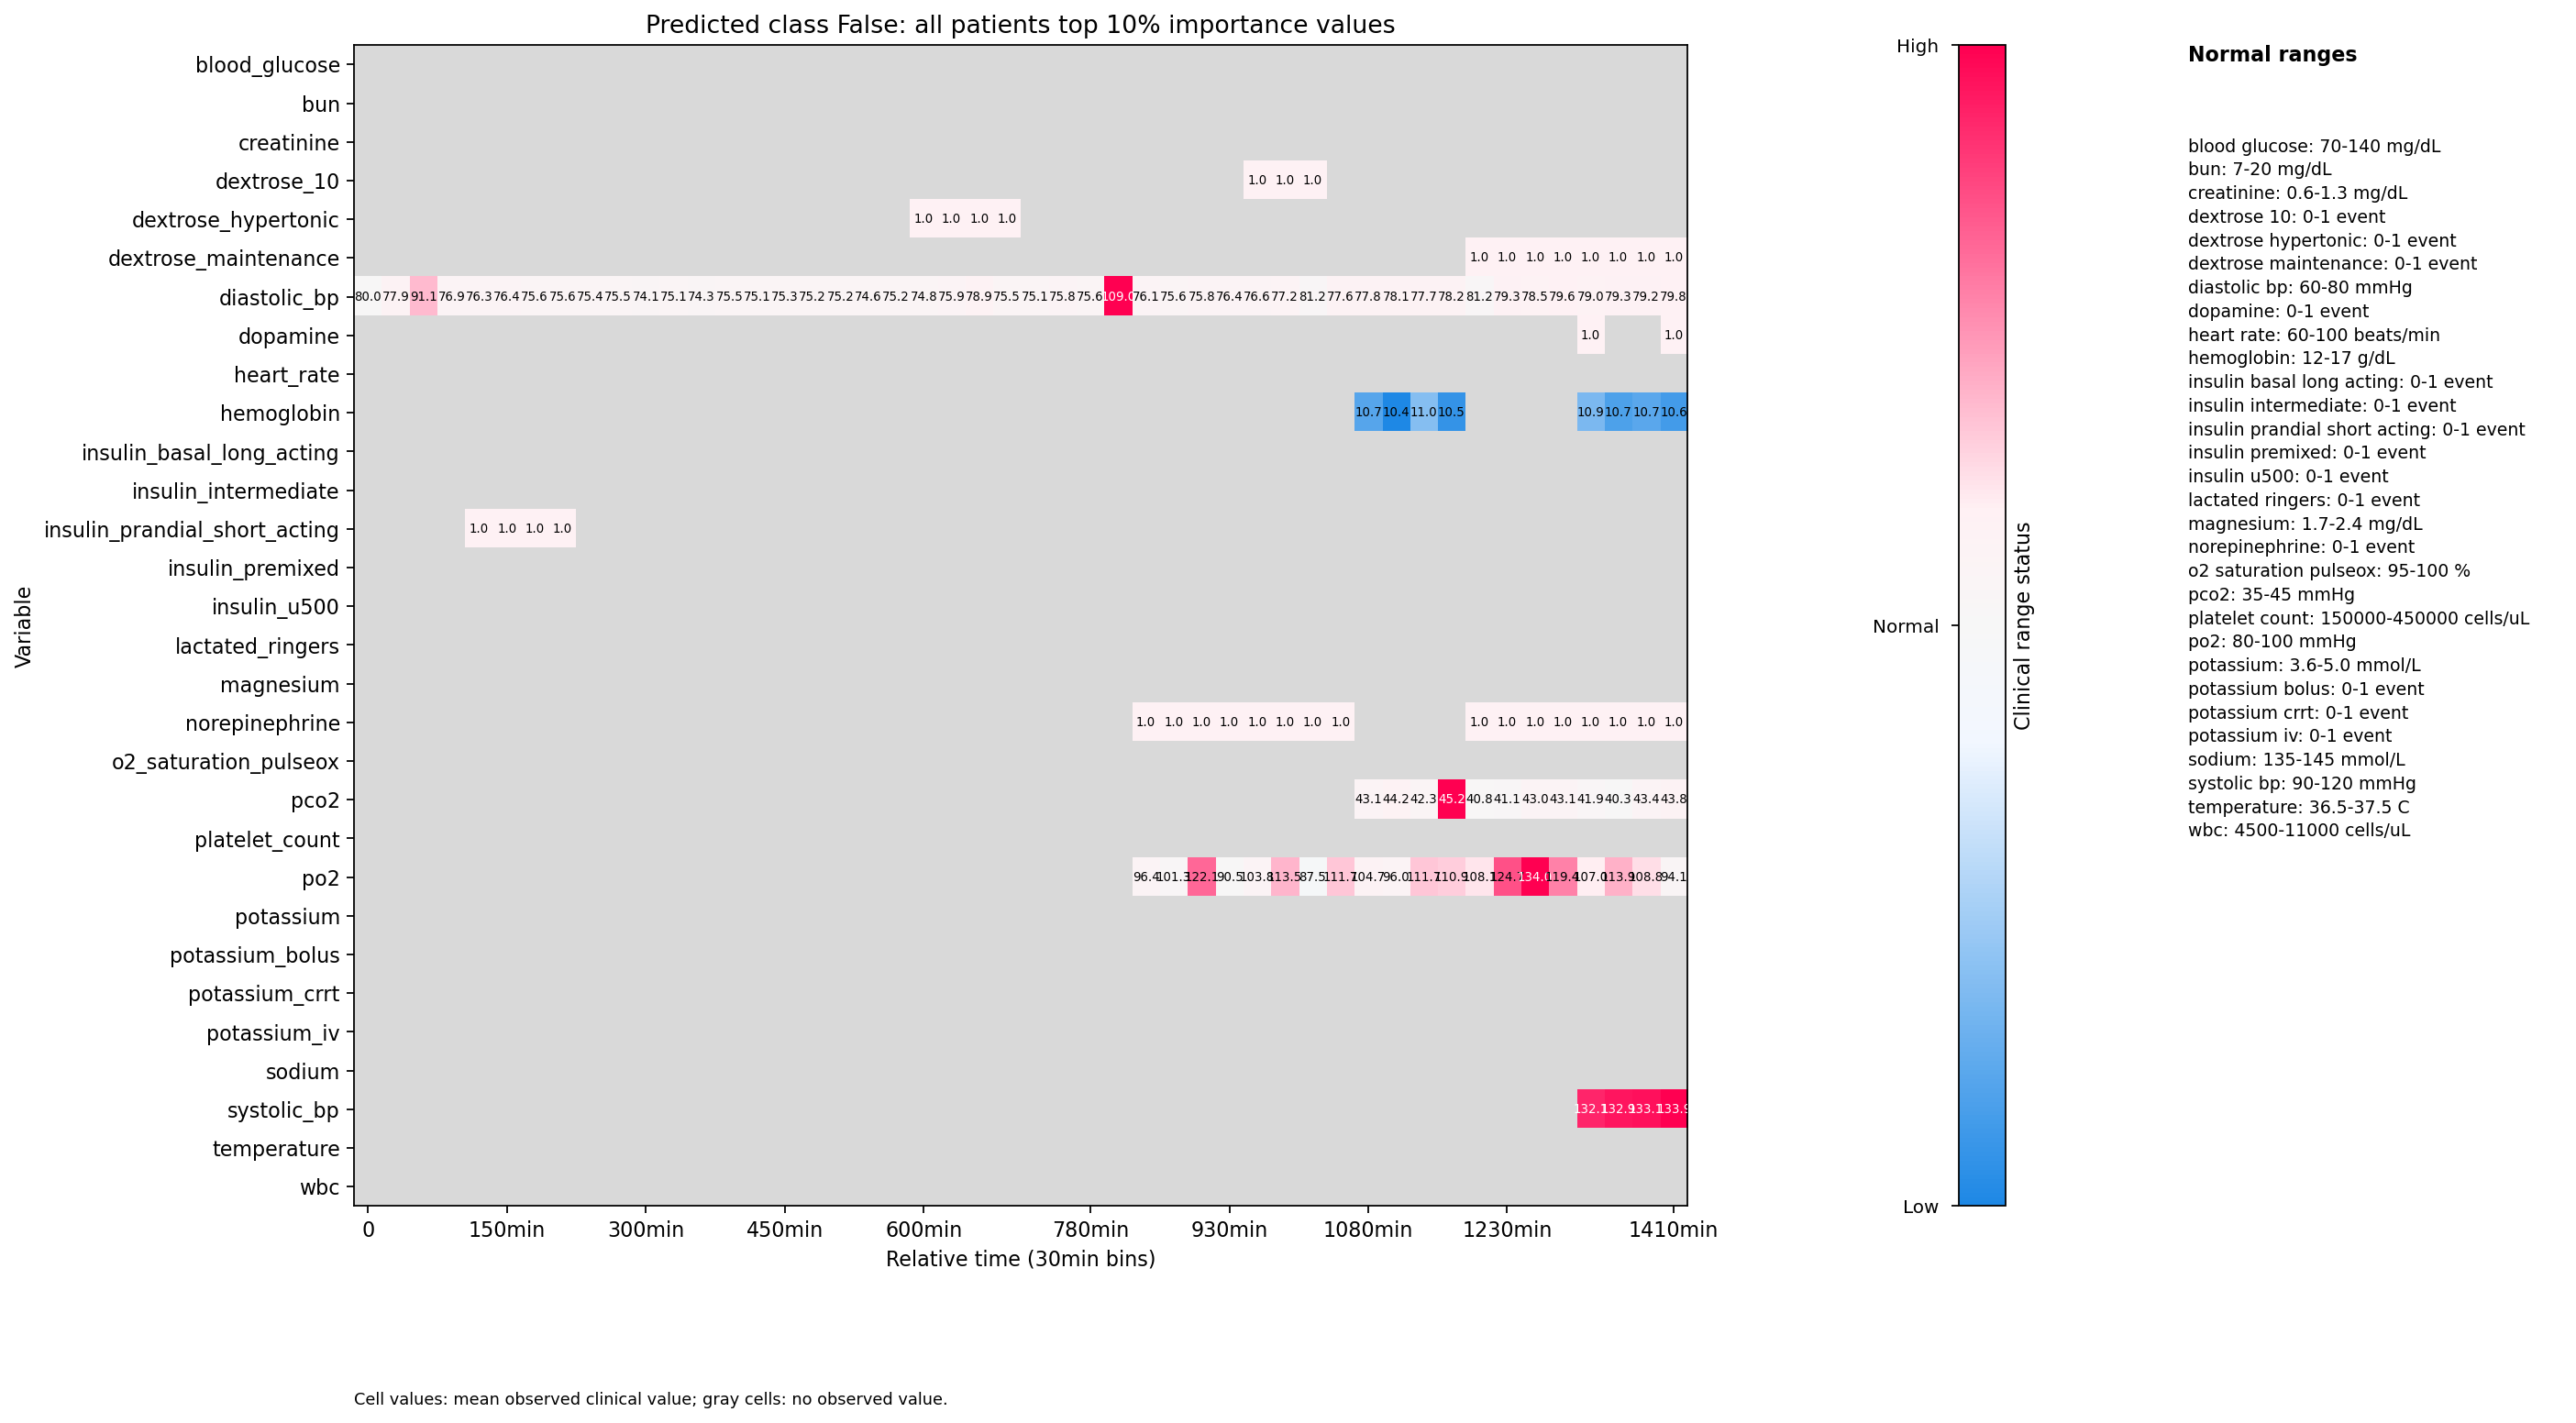

/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/pattern_heatmaps/test/True/class_pattern_top_importance_10pct.png


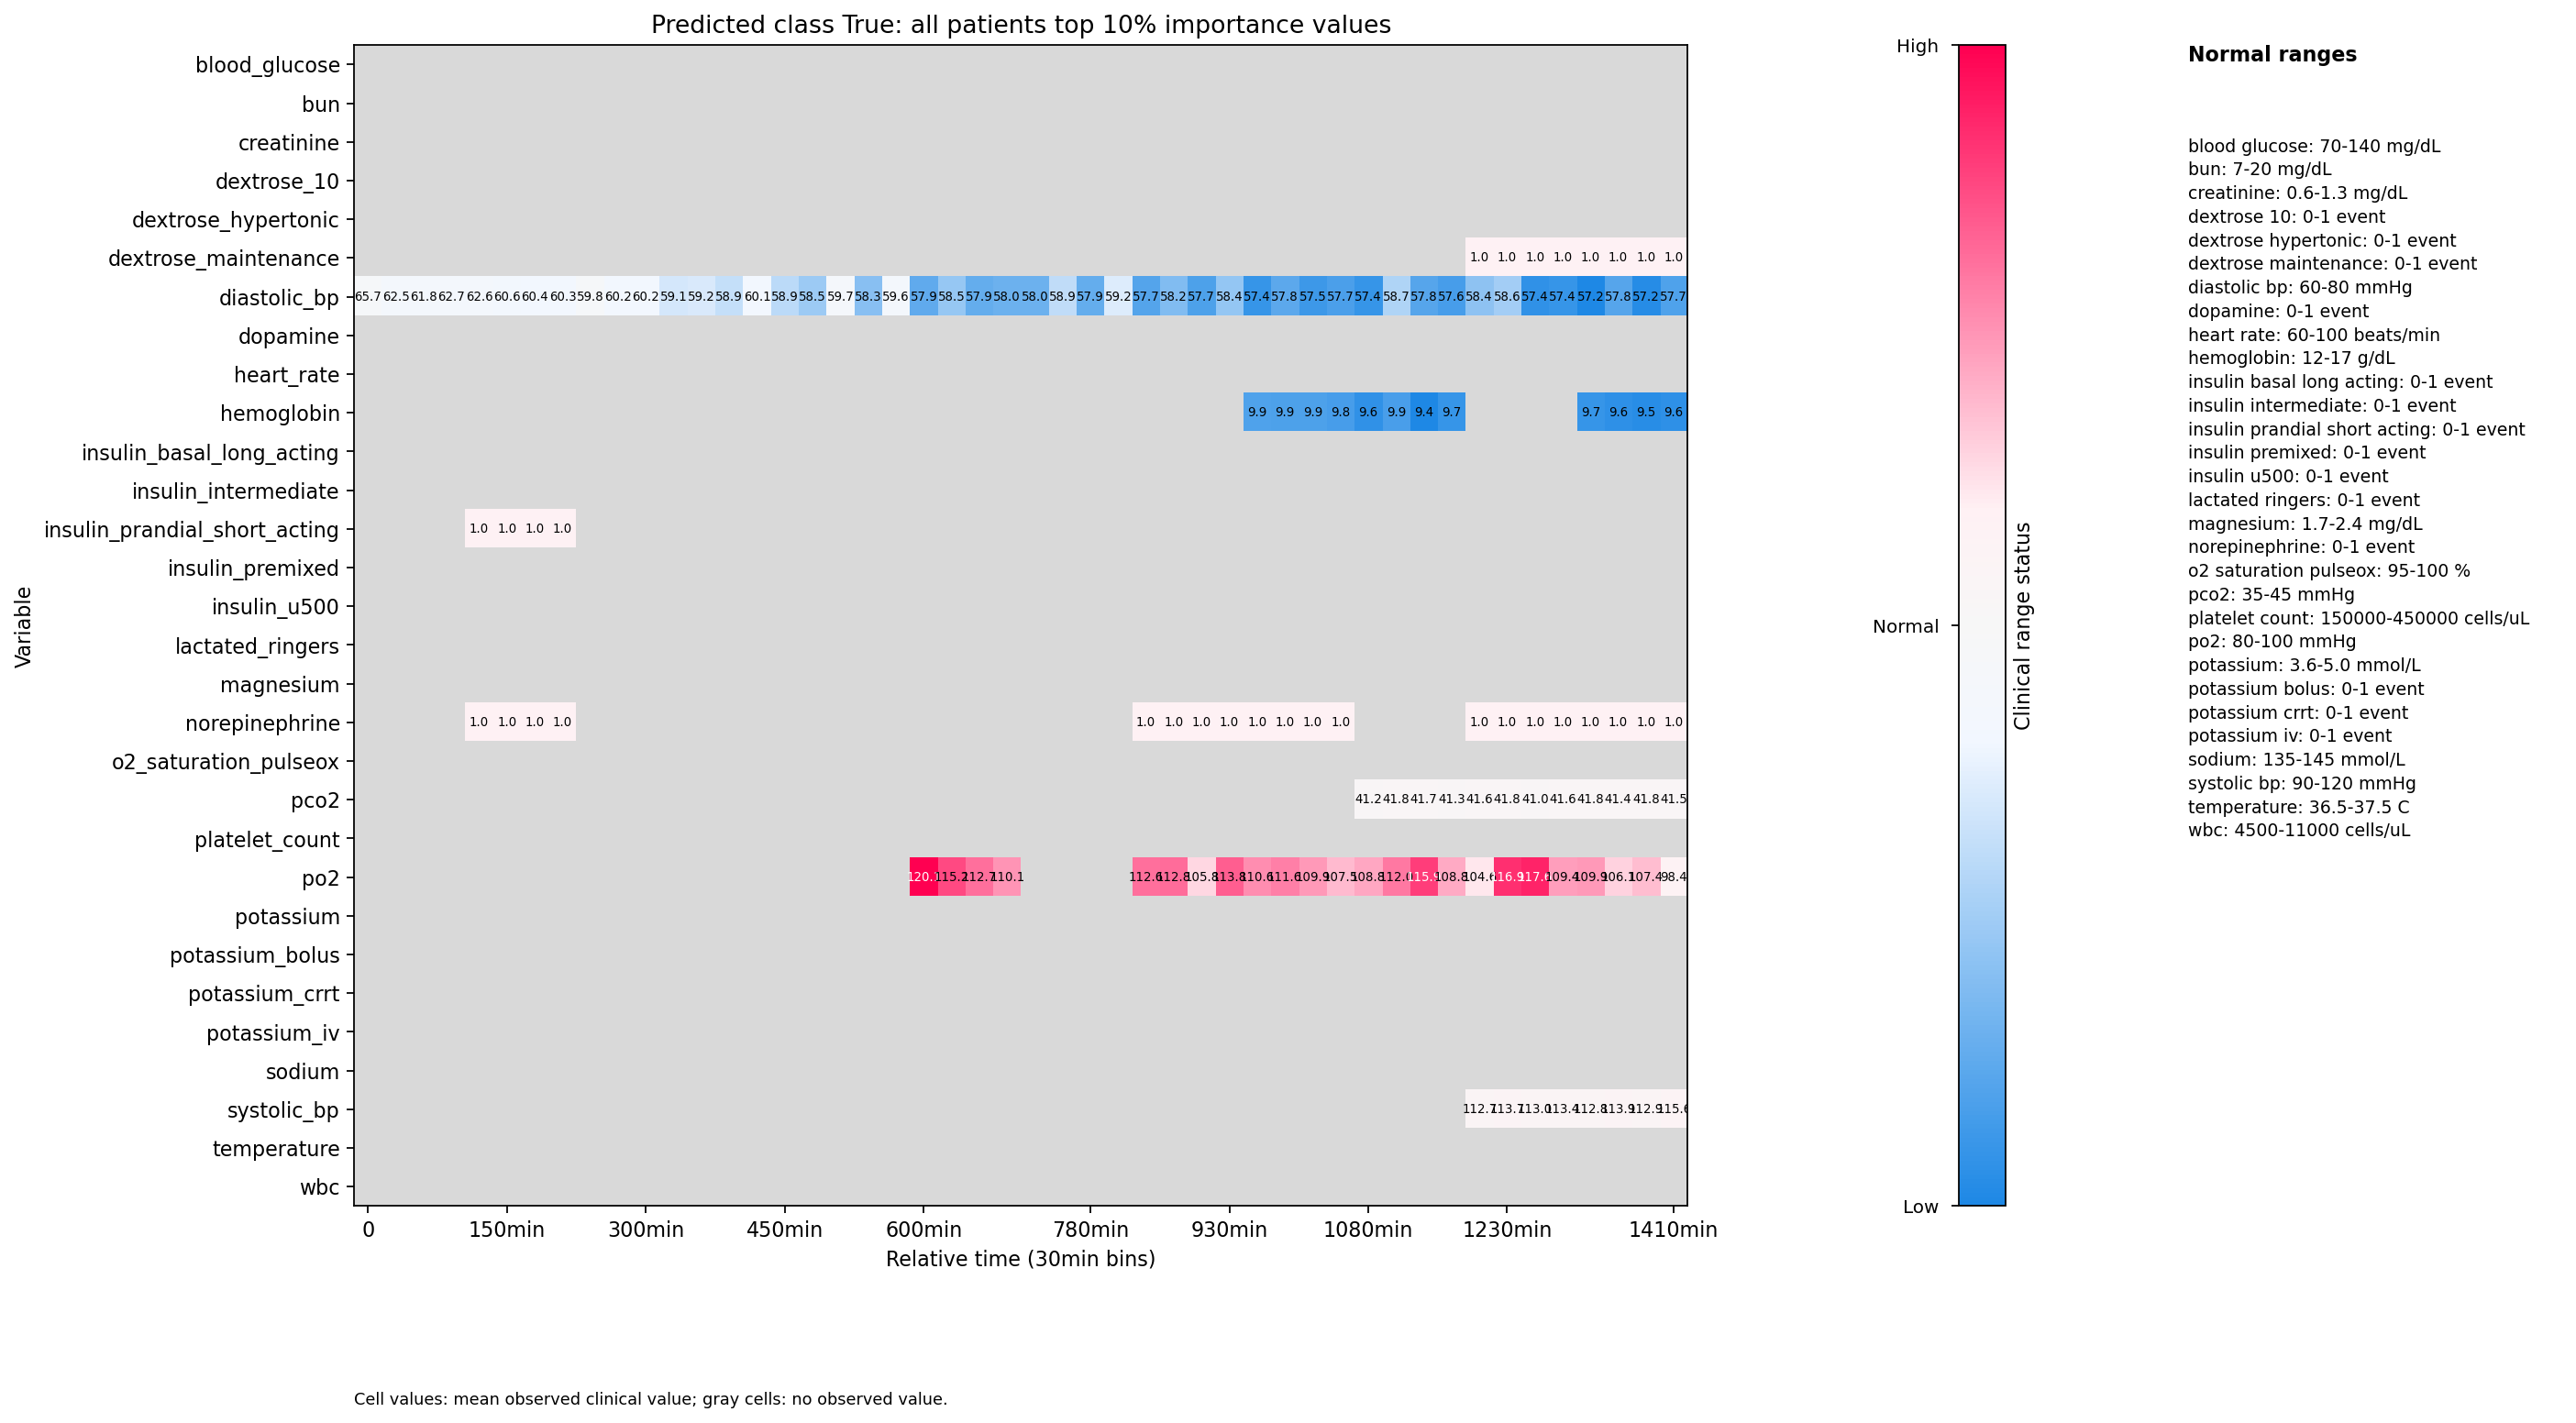

2026-07-15 20:21:44,879 INFO unified_mimic_target_workflow: Saved visualization manifest to /home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/pattern_heatmaps/test/visualization_manifest.csv


,pattern_type,class,cluster,threshold,path
0,class,False,None,0.1,/home/michalwe/Interpretable-ViT-for-Timeserie...
1,class,True,None,0.1,/home/michalwe/Interpretable-ViT-for-Timeserie...


In [13]:
PLOT_TOP_IMPORTANCE_THRESHOLD = 0.1


def top_importance_value_matrix(value_matrix, importance_matrix, threshold=PLOT_TOP_IMPORTANCE_THRESHOLD):
    threshold = float(threshold)
    if not 0.0 < threshold <= 1.0:
        raise ValueError("threshold must be in (0, 1]. For example, 0.1 plots the top 10% importance scores.")
    if importance_matrix.shape != value_matrix.shape:
        raise ValueError(f"Importance matrix shape {importance_matrix.shape} does not match value matrix shape {value_matrix.shape}.")
    finite_mask = np.isfinite(value_matrix) & np.isfinite(importance_matrix)
    finite_importance = importance_matrix[finite_mask]
    if finite_importance.size == 0:
        raise ValueError("No finite value/importance cells are available for top-importance plotting.")
    cutoff = np.quantile(finite_importance, 1.0 - threshold)
    top_mask = finite_mask & (importance_matrix >= cutoff)
    top_matrix = np.full_like(value_matrix, np.nan, dtype=np.float64)
    top_matrix[top_mask] = value_matrix[top_mask]
    return top_matrix


def pattern_heatmap_path(pattern_type: str, class_label: str, cluster: int | None = None) -> Path:
    class_dir = pattern_heatmap_dir / safe_path_component(class_label)
    suffix = f"top_importance_{int(round(PLOT_TOP_IMPORTANCE_THRESHOLD * 100))}pct"
    if cluster is None:
        return class_dir / f"{pattern_type}_pattern_{suffix}.png"
    return class_dir / f"cluster_{int(cluster)}_pattern_{suffix}.png"


def plot_pattern_matrix(value_matrix: np.ndarray, importance_matrix: np.ndarray, output_path: Path, title: str) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    matrix_for_plot = top_importance_value_matrix(value_matrix, importance_matrix, PLOT_TOP_IMPORTANCE_THRESHOLD)
    vmin, vmax = value_ranges_by_variable([matrix_for_plot])
    plot_value_heatmap(
        matrix_for_plot,
        binner.variable_vocab_,
        binner.time_bins_,
        output_path,
        title=f"{title} top {PLOT_TOP_IMPORTANCE_THRESHOLD:.0%} importance values",
        vmin=vmin,
        vmax=vmax,
        show_values=SHOW_VALUES,
        normal_ranges=normal_ranges_arg(),
    )
    print(output_path)
    display(Image(filename=str(output_path)))
    return output_path


if FORCE_PLOTS and pattern_heatmap_dir.exists():
    logger.warning("FORCE_PLOTS=True; removing %s", pattern_heatmap_dir)
    remove_path(pattern_heatmap_dir)

plot_paths = []
for class_label, value_matrix in class_plot_matrices.items():
    path = pattern_heatmap_path("class", class_label)
    if path.exists() and not FORCE_PLOTS:
        print(path)
        display(Image(filename=str(path)))
    else:
        plot_pattern_matrix(
            value_matrix,
            class_importance_matrices[class_label],
            path,
            f"Predicted class {class_label}: all patients",
        )
    plot_paths.append({"pattern_type": "class", "class": class_label, "cluster": None, "threshold": PLOT_TOP_IMPORTANCE_THRESHOLD, "path": str(path)})

if CLUSTER:
    for (class_label, cluster), value_matrix in sorted(cluster_plot_matrices.items()):
        path = pattern_heatmap_path("cluster", class_label, cluster)
        if path.exists() and not FORCE_PLOTS:
            print(path)
            display(Image(filename=str(path)))
        else:
            plot_pattern_matrix(
                value_matrix,
                cluster_importance_matrices[(class_label, cluster)],
                path,
                f"Predicted class {class_label}: cluster_{cluster}",
            )
        plot_paths.append({"pattern_type": "cluster", "class": class_label, "cluster": cluster, "threshold": PLOT_TOP_IMPORTANCE_THRESHOLD, "path": str(path)})

visualization_manifest = pd.DataFrame(plot_paths)
visualization_manifest_path = pattern_heatmap_dir / "visualization_manifest.csv"
visualization_manifest_json_path = pattern_heatmap_dir / "visualization_manifest.json"
pattern_heatmap_dir.mkdir(parents=True, exist_ok=True)
visualization_manifest.to_csv(visualization_manifest_path, index=False)
visualization_manifest_json_path.write_text(json.dumps(jsonable(plot_paths), indent=2), encoding="utf-8")
logger.info("Saved visualization manifest to %s", visualization_manifest_path)
display(visualization_manifest)


## 13. Artifact Summary

In [14]:
summary_items = [
    {"category": "configuration", "artifact": "experiment_config", "path": run_dir / "experiment_config.json"},
    {"category": "data", "artifact": "train_tensor", "path": processed_dir / "train.npz"},
    {"category": "data", "artifact": "val_tensor", "path": processed_dir / "val.npz"},
    {"category": "data", "artifact": "test_tensor", "path": processed_dir / "test.npz"},
    {"category": "model", "artifact": "trained_model", "path": run_dir / "model.pt"},
    {"category": "metrics", "artifact": "evaluation_metrics", "path": run_dir / f"{SPLIT}_evaluation_metrics.json"},
    {"category": "metrics", "artifact": "model_evaluation_metrics", "path": run_dir / f"model_evaluation_metrics_{SPLIT}.json"},
    {"category": "predictions", "artifact": "predictions", "path": run_dir / f"{SPLIT}_predictions.csv"},
    {"category": "statistics", "artifact": "patient_pattern_similarity", "path": run_dir / f"{SPLIT}_pattern_similarity.csv"},
    {"category": "statistics", "artifact": "class_similarity_tests", "path": run_dir / f"{SPLIT}_class_similarity_tests.csv"},
    {"category": "explanations", "artifact": f"{SPLIT}_explanations", "path": explanations_root / SPLIT},
    {"category": "visualizations", "artifact": "pattern_heatmaps", "path": pattern_heatmap_dir},
    {"category": "visualizations", "artifact": "visualization_manifest_csv", "path": pattern_heatmap_dir / "visualization_manifest.csv"},
    {"category": "visualizations", "artifact": "visualization_manifest_json", "path": pattern_heatmap_dir / "visualization_manifest.json"},
]
if CLUSTER:
    summary_items.extend([
        {"category": "explanations", "artifact": "train_explanations", "path": explanations_root / "train"},
        {"category": "explanations", "artifact": "val_explanations", "path": explanations_root / "val"},
        {"category": "autoencoder", "artifact": "autoencoder_model", "path": clusters_dir / "autoencoder.pt"},
        {"category": "autoencoder", "artifact": "autoencoder_embeddings", "path": clusters_dir / "autoencoder_embeddings.csv"},
        {"category": "clusters", "artifact": "cluster_assignments", "path": clusters_dir / "cluster_assignments.csv"},
        {"category": "clusters", "artifact": "cluster_centroids", "path": clusters_dir / "cluster_centroids.csv"},
        {"category": "clusters", "artifact": "cluster_metadata", "path": clusters_dir / "cluster_metadata.json"},
        {"category": "clusters", "artifact": "silhouette_scores", "path": clusters_dir / "silhouette_cluster_scores.csv"},
        {"category": "statistics", "artifact": "cluster_similarity_tests", "path": run_dir / f"{SPLIT}_cluster_similarity_tests.csv"},
    ])

artifact_summary = pd.DataFrame([
    {**item, "exists": Path(item["path"]).exists(), "path": str(item["path"])}
    for item in summary_items
])
artifact_summary_path = run_dir / f"{SPLIT}_artifact_summary.csv"
artifact_summary.to_csv(artifact_summary_path, index=False)
display(artifact_summary)
print(f"Artifact summary saved to: {artifact_summary_path}")


,category,artifact,path,exists
0,configuration,experiment_config,/home/michalwe/Interpretable-ViT-for-Timeserie...,True
1,data,train_tensor,/home/michalwe/Interpretable-ViT-for-Timeserie...,True
2,data,val_tensor,/home/michalwe/Interpretable-ViT-for-Timeserie...,True
3,data,test_tensor,/home/michalwe/Interpretable-ViT-for-Timeserie...,True
4,model,trained_model,/home/michalwe/Interpretable-ViT-for-Timeserie...,True
5,metrics,evaluation_metrics,/home/michalwe/Interpretable-ViT-for-Timeserie...,True
6,metrics,model_evaluation_metrics,/home/michalwe/Interpretable-ViT-for-Timeserie...,True
7,predictions,predictions,/home/michalwe/Interpretable-ViT-for-Timeserie...,True
8,statistics,patient_pattern_similarity,/home/michalwe/Interpretable-ViT-for-Timeserie...,True
9,statistics,class_similarity_tests,/home/michalwe/Interpretable-ViT-for-Timeserie...,True


Artifact summary saved to: /home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/test_artifact_summary.csv
